# [실습1] LangGraph

## 실습 목표
---
엑셀 데이터 분석과 RAG 기능을 모두 활용하기 위해, 그래프 구조의 챗봇을 구성할 수 있는 LangGraph의 기초를 학습합니다.

## 실습 목차
---

1. **LangGraph:** 체인을 넘어서 그래프 구조를 구성하기 위해 LangChain의 기초를 학습하고, 1챕터에서 구현한 간단한 LLM 챗봇을 다시 한번 구성합니다.

## 실습 개요
---
그래프 구조의 챗봇을 구성할 수 있는 LangGraph를 사용해 봅니다.

## 0. 환경 설정
- 필요한 라이브러리를 불러옵니다.

In [2]:
from typing import Annotated

from IPython.display import Image, display
from langchain_community.chat_models import ChatOllama
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

- Ollama를 통해 Mistral 7B 모델을 불러옵니다. 처음 불러오는데는 다운로드 시간 포함 약 3분이 소요됩니다.

In [3]:
# !ollama pull mistral:7b

## 1. LangGraph
- 체인을 넘어서 그래프 구조를 구성하기 위해 LangChain의 기초를 학습합니다.

먼저, mistral:7b 모델을 사용하는 ChatOllama 객체를 생성합니다.

In [4]:
llm = ChatOllama(model="mistral:7b")
tool_llm = ChatOllama(model="mistral:7b") 

이번 실습에서는 매우 간단한 챗봇을 하나 만들어 볼 것입니다. LLM에 질문을 입력하면 LLM은 별다른 액션을 취하지 않고 바로 질문에 대답할 것입니다.

앞서 체인을 구성할 때는 | 연산자를 통해 Agent, Tool 등 여러 구성 요소를 엮어 하나의 체인으로 만들었습니다.

LangGraph의 그래프를 구성할 때는 `StateGraph` 객체를 생성하고, 여기에 `Node` (노드) 와 `Edge` (엣지, 간선)를 추가하여 하나의 그래프로 만들 수 있습니다.

In [5]:
class State(TypedDict):
    # `State` class를 정의해서 그래프의 각 구성 요소 간에 전달할 정보의 속성을 정의합니다.
    # Message는 "List" type을 가집니다. annotation의 `add_messages` 함수는
    # 이 state key가 어떻게 업데이트 되어야 하는지 정의합니다.
    messages: Annotated[list, add_messages]


# 그래프를 구성하기 위해 StateGraph 객체를 생성합니다.
# 생성자의 인자로 State를 전달하여 Node 간에 정보를 전달할 때 State type을 사용함을 명시합니다.
graph_builder = StateGraph(State)

그래프는 Node와 Edge로 구성되어 있습니다.

Node는 체인의 각 구성 요소에 대응합니다. Agent, Tool, LLM 등 그래프의 각 구성 요소를 의미합니다.

Edge는 Node를 연결하는 요소로, Node에서 정보를 어느 Node로 전달해야 하는지를 나타냅니다.
- 체인은 일렬로 이어져 있기 때문에, 사용자의 입력을 연결된 순서대로 통과시키면 원하는 결과를 얻을 수 있습니다.
- 하지만, 그래프는 일렬로 이어져 있지 않기 때문에 Edge를 통해 정보를 전달하는 순서 및 방향을 정해줘야 합니다.

여기서는 간단한 챗봇을 만들기 위해 (시작 지점과 끝점을 제외한) 단일 노드 그래프를 만들어 보겠습니다.

In [6]:
## Node 생성
# Node는 그래프에서 실행될 수 있는 작업을 정의합니다.
# Node는 함수로 정의되며, StateGraph를 정의할 때 사용한 State type을 입력으로 받습니다.
# Node는 state를 업데이트하거나, 새로운 state를 반환할 수 있습니다.
def answer(state: State):
    # 단순 챗봇이므로, 입력받은 메시지를 LLM에 입력하고, 그 결과를 반환합니다.
    return {"messages": [llm.invoke(state["messages"])]}  # State내 messages의 value가 list형태라서 [ ] 로 감싸줌.

## Node 추가
# 그래프에 Node를 추가합니다.
# add_node 함수의 첫 번째 인자는 Node의 이름입니다. (함수 이름과 달라도 됩니다)
# Node의 이름은 특정 노드에서 다른 노드를 호출할 때 사용합니다.
# 두 번째 인자는 Node가 호출될 때 실행될 함수입니다.
graph_builder.add_node("answer", answer)

# 그래프를 실행할 때 시작점이 되는 Node를 설정합니다. (Node 이름을 전달합니다)
# 이 경우, 사용자의 입력을 받아 `answer` 노드를 가장 먼저 실행하게 됩니다.
graph_builder.set_entry_point("answer")
# 그래프를 실행할 때 종료점이 되는 Node를 설정합니다. (Node 이름을 전달합니다)
# 이 경우, `answer` 노드가 실행된 후 사용자에게 결과를 반환하고 그래프를 종결합니다.
graph_builder.set_finish_point("answer")

그래프 구성을 종료했으면, 이제 그래프를 컴파일하여 사용할 수 있습니다.

컴파일 완료된 그래프는 "Runnable" 한 객체입니다.<br>
즉, `invoke()` 메서드를 통해 그래프를 사용할 수 있고, 앞서 배운 체인의 구성 요소로 사용할 수 있습니다.

In [7]:
graph = graph_builder.compile()

컴파일된 그래프의 구조를 시각화 해봅시다.

단일 노드 그래프이기 떄문에 시작점, 끝점을 제외하면 노드 간의 Edge가 없는 것을 확인할 수 있습니다.

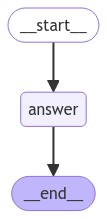

In [8]:
display(Image(graph.get_graph().draw_mermaid_png()))

이제 챗봇을 사용해봅시다. 
- 시스템 프롬프트에 별도로 한글 텍스트를 추가하지 않았고, 한글로 답변하라는 프롬프트도 없기 때문에 대부분 영어로 답변합니다.

In [9]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    else:
        # graph.stream 함수를 사용하여 그래프를 실행하고, 각 Node의 결과를 반환합니다.
        for event in graph.stream({"messages": ("user", question)}):
            # 각 Node의 결과를 출력합니다.
            for value in event.values():
                print("Assistant:", value["messages"][-1].content)

Failed to batch ingest runs: LangSmithError('Failed to POST https://api.smith.langchain.com/runs/batch in LangSmith API. HTTPError(\'403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/batch\', \'{"detail":"Forbidden"}\')')


OllamaEndpointNotFoundError: Ollama call failed with status code 404. Maybe your model is not found and you should pull the model with `ollama pull mistral:7b`.

Failed to batch ingest runs: LangSmithError('Failed to POST https://api.smith.langchain.com/runs/batch in LangSmith API. HTTPError(\'403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/batch\', \'{"detail":"Forbidden"}\')')


In [ ]:
# 아래 코드의 주석을 해제하고 실행하면 본 실습에서 다운받은 모델 파일을 삭제합니다.
# 각 실습에서 같은 모델이라도 다시 다운 받기 때문에, 
# 실습이 종료되었으면 아래 명령어를 실행하여 불필요한 파일을 삭제하는 것이 좋습니다.
# !rm -rf .ollama/models/*